# Graph Coloring and the Chromatic Number

A **proper $k$-coloring** of a graph $G = (V, E)$ assigns a color $c: V \to \{1,\ldots,k\}$ such that adjacent vertices receive different colors. The **chromatic number** $\chi(G)$ is the minimum $k$ for which a proper coloring exists.

## Bounds

- **Lower bound**: $\chi(G) \ge \omega(G)$ where $\omega(G)$ is the clique number.
- **Upper bound**: $\chi(G) \le \Delta(G) + 1$ (Brooks' theorem: $\chi \le \Delta$ unless $G$ is a complete graph or odd cycle).
- For planar graphs: $\chi(G) \le 4$ (Four Color Theorem).

## Greedy coloring

Process vertices in some order $v_1, \ldots, v_n$ and assign the smallest color not used by already-colored neighbors. This gives $\chi \le \Delta + 1$ but may waste colors.

## DSatur algorithm

DSatur (Brélaz 1979) greedily selects the vertex with the **highest saturation** — the number of distinct colors in its neighborhood. Ties are broken by degree. This heuristic often achieves close to optimal coloring.

## Applications

- **Register allocation** in compilers: variables are nodes, edges = simultaneous liveness, colors = registers.
- **Scheduling**: time slots = colors, conflicts = overlapping tasks.
- **Frequency assignment** in wireless networks.
- **Map coloring**: adjacent regions must have different colors (Four Color Theorem).

## Delaunay graph

Given points in $\mathbb{R}^2$, the **Delaunay triangulation** connects every point to its natural neighbors. Coloring this graph with few colors demonstrates planarity in practice.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from ipywidgets import interact, IntSlider

plt.rcParams['figure.dpi'] = 120

## Greedy and DSatur coloring

We implement both algorithms. The graph is represented as an adjacency list.

In [2]:
def greedy_color(adj, order=None):
    n = len(adj)
    if order is None: order = list(range(n))
    colors = [-1] * n
    for v in order:
        used = {colors[u] for u in adj[v] if colors[u] >= 0}
        c = 0
        while c in used: c += 1
        colors[v] = c
    return colors

def dsatur_color(adj):
    n = len(adj)
    colors = [-1] * n
    degree = [len(adj[v]) for v in range(n)]
    saturation = [0] * n
    neighbor_colors = [set() for _ in range(n)]

    for step in range(n):
        # pick vertex with max saturation (tie-break: degree)
        uncolored = [v for v in range(n) if colors[v] < 0]
        v = max(uncolored, key=lambda x: (saturation[x], degree[x]))
        # assign smallest available color
        c = 0
        while c in neighbor_colors[v]: c += 1
        colors[v] = c
        # update saturation of neighbors
        for u in adj[v]:
            if colors[u] < 0 and c not in neighbor_colors[u]:
                neighbor_colors[u].add(c)
                saturation[u] += 1
    return colors

def delaunay_graph(pts):
    tri = Delaunay(pts)
    n = len(pts)
    adj = [set() for _ in range(n)]
    for s in tri.simplices:
        for i in range(3):
            for j in range(3):
                if i != j:
                    adj[s[i]].add(s[j])
    return [sorted(a) for a in adj], tri

print('Graph coloring algorithms ready.')

Graph coloring algorithms ready.


## Coloring a Delaunay graph

We generate random points, build the Delaunay graph, and color it with both algorithms.

Greedy: 5 colors
DSatur: 4 colors


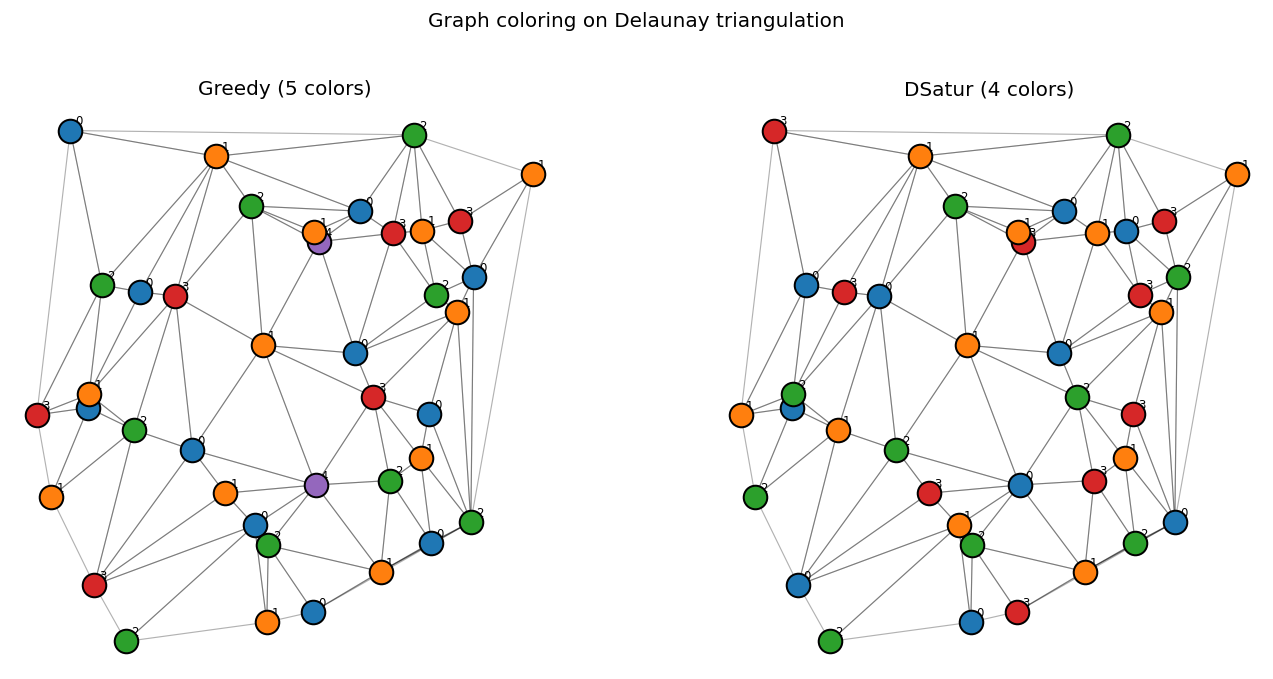

In [3]:
rng = np.random.default_rng(42)
n_pts = 40
pts = rng.uniform(0, 1, (n_pts, 2))
adj, tri = delaunay_graph(pts)

c_greedy = greedy_color(adj)
c_dsatur = dsatur_color(adj)

print(f'Greedy: {max(c_greedy)+1} colors')
print(f'DSatur: {max(c_dsatur)+1} colors')

palette = plt.cm.tab10(np.linspace(0, 0.9, 10))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, (colors, title) in zip(axes, [(c_greedy, f'Greedy ({max(c_greedy)+1} colors)'),
                                       (c_dsatur, f'DSatur ({max(c_dsatur)+1} colors)')]):
    # Draw edges
    for s in tri.simplices:
        for i in range(3):
            for j in range(i+1, 3):
                ax.plot(pts[[s[i],s[j]],0], pts[[s[i],s[j]],1], 'k-', lw=0.7, alpha=0.3)
    # Draw nodes
    for v in range(n_pts):
        ax.scatter(pts[v,0], pts[v,1], color=palette[colors[v] % 10], s=200,
                   edgecolors='black', linewidths=1.2, zorder=5)
        ax.text(pts[v,0]+0.01, pts[v,1]+0.01, str(colors[v]), fontsize=7)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)

fig.suptitle('Graph coloring on Delaunay triangulation', y=1.02)
plt.tight_layout(); plt.show()

## Chromatic number lower bounds: clique detection

A clique of size $\omega$ gives $\chi \ge \omega$. We find a greedy clique in the Delaunay graph.

Greedy clique size: 3 → χ ≥ 3


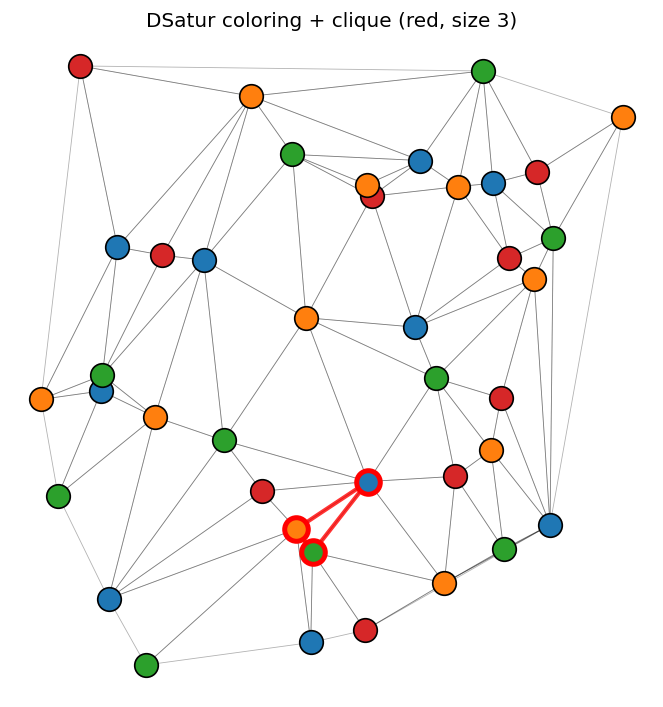

In [4]:
def greedy_clique(adj):
    n = len(adj)
    clique = []
    candidates = list(range(n))
    # Start with highest degree
    v = max(candidates, key=lambda x: len(adj[x]))
    clique.append(v)
    candidates = [u for u in adj[v]]
    while candidates:
        v = max(candidates, key=lambda x: sum(1 for w in candidates if w in adj[x]))
        clique.append(v)
        candidates = [u for u in candidates if u in adj[v]]
    return clique

clique = greedy_clique(adj)
print(f'Greedy clique size: {len(clique)} → χ ≥ {len(clique)}')

fig, ax = plt.subplots(figsize=(6, 6))
for s in tri.simplices:
    for i in range(3):
        for j in range(i+1, 3):
            ax.plot(pts[[s[i],s[j]],0], pts[[s[i],s[j]],1], 'k-', lw=0.5, alpha=0.3)

colors_d = c_dsatur
for v in range(n_pts):
    ec = 'red' if v in clique else 'black'
    lw = 3 if v in clique else 1
    ax.scatter(pts[v,0], pts[v,1], color=palette[colors_d[v] % 10], s=200,
               edgecolors=ec, linewidths=lw, zorder=5)

# Highlight clique edges
for i, v in enumerate(clique):
    for w in clique[i+1:]:
        ax.plot(pts[[v,w],0], pts[[v,w],1], 'r-', lw=2.5, alpha=0.8, zorder=4)

ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'DSatur coloring + clique (red, size {len(clique)})')
plt.tight_layout(); plt.show()

## Interactive: number of points

In [5]:
def show_coloring(n_pts=30, seed=42):
    rng2 = np.random.default_rng(seed)
    pts2 = rng2.uniform(0, 1, (n_pts, 2))
    adj2, tri2 = delaunay_graph(pts2)
    c_g = greedy_color(adj2)
    c_d = dsatur_color(adj2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (colors, title) in zip(axes, [(c_g, f'Greedy ({max(c_g)+1} colors)'),
                                           (c_d, f'DSatur ({max(c_d)+1} colors)')]):
        for s in tri2.simplices:
            for i in range(3):
                for j in range(i+1,3):
                    ax.plot(pts2[[s[i],s[j]],0], pts2[[s[i],s[j]],1],'k-',lw=0.6,alpha=0.3)
        for v in range(n_pts):
            ax.scatter(pts2[v,0], pts2[v,1], color=palette[colors[v]%10], s=180,
                       edgecolors='k', linewidths=1, zorder=5)
        ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)
    plt.tight_layout(); plt.show()

interact(show_coloring,
         n_pts=IntSlider(value=30, min=10, max=80, step=5, description='$n$'),
         seed=IntSlider(value=42, min=0, max=100, step=1, description='seed'));

interactive(children=(IntSlider(value=30, description='$n$', max=80, min=10, step=5), IntSlider(value=42, desc…

## Bibliographical resources

- Brélaz, D. (1979). New methods to color the vertices of a graph. *Communications of the ACM*, 22(4), 251–256.
- Brooks, R. L. (1941). On colouring the nodes of a network. *Mathematical Proceedings of the Cambridge Philosophical Society*, 37(2), 194–197.
- Appel, K. and Haken, W. (1977). Every planar map is four colorable. *Illinois Journal of Mathematics*, 21(3), 429–567.
- Jensen, T. R. and Toft, B. (1995). *Graph Coloring Problems*. Wiley.
- Garey, M. R. and Johnson, D. S. (1979). *Computers and Intractability: A Guide to the Theory of NP-Completeness*. Freeman.